<a href="https://colab.research.google.com/github/brahmanbhavika06-sketch/my-colab-code/blob/main/session28.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv(
    '/content/train.txt',
    sep=';',
    names=['text', 'emotions']
)

# Display first 10 rows
print("First 10 rows:")
display(df.head(10))

# Display shape
print("\nShape of dataset:")
print(df.shape)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

First 10 rows:


,text,emotions
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love



Shape of dataset:
(16000, 2)

Missing values:
text        0
emotions    0
dtype: int64


In [ ]:
# Q2. Exploring Target Labels

from sklearn.preprocessing import LabelEncoder

# Find and print all unique emotion labels
print("Unique Emotion Labels:")
print(df['emotions'].unique())

# Create LabelEncoder
label_encoder = LabelEncoder()

# Convert emotion labels into numeric values
df['emotion_encoded'] = label_encoder.fit_transform(df['emotions'])

# Create mapping dictionary
emotion_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

# Display mapping
print("\nEmotion Mapping:")
print(emotion_mapping)

# Display dataset with encoded labels
print("\nDataset with Encoded Labels:")
display(df.head(10))

Unique Emotion Labels:
['sadness' 'anger' 'love' 'surprise' 'fear' 'joy']

Emotion Mapping:
{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}

Dataset with Encoded Labels:


,text,emotions,emotion_encoded
0,i didnt feel humiliated,sadness,4
1,i can go from feeling so hopeless to so damned...,sadness,4
2,im grabbing a minute to post i feel greedy wrong,anger,0
3,i am ever feeling nostalgic about the fireplac...,love,3
4,i am feeling grouchy,anger,0
5,ive been feeling a little burdened lately wasn...,sadness,4
6,ive been taking or milligrams or times recomme...,surprise,5
7,i feel as confused about life as a teenager or...,fear,1
8,i have been with petronas for years i feel tha...,joy,2
9,i feel romantic too,love,3


In [ ]:
# Q3. Lowercasing

# Keep original text for comparison
df['text_original'] = df['text']

# Convert entire text column to lowercase
df['text'] = df['text'].str.lower()

# Show 5 sample texts before and after lowercasing
print("Before and After Lowercasing:\n")

for i in range(5):
    print("Before:", df['text_original'].iloc[i])
    print("After :", df['text'].iloc[i])
    print("-" * 80)

# Short note
print("\nWhy is Lowercasing Important in NLP?")
print("Lowercasing makes text consistent by treating uppercase and lowercase")
print("versions of the same word as the same word. It reduces unnecessary")
print("variations in the text and helps improve NLP text processing.")

Before and After Lowercasing:

Before: i didnt feel humiliated
After : i didnt feel humiliated
--------------------------------------------------------------------------------
Before: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
After : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
--------------------------------------------------------------------------------
Before: im grabbing a minute to post i feel greedy wrong
After : im grabbing a minute to post i feel greedy wrong
--------------------------------------------------------------------------------
Before: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
After : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
--------------------------------------------------------------------------------
Before: i am feeling grouchy
Af

In [ ]:
# Q4. Removing Punctuation

import string

# Function to remove punctuation
def remove_punctuation(text):
    return text.translate(
        str.maketrans('', '', string.punctuation)
    )

# Apply function to text column
df['text_no_punctuation'] = df['text'].apply(remove_punctuation)

# Display 5 examples before and after punctuation removal
print("Before and After Punctuation Removal:\n")

for i in range(5):
    print("Before:", df['text'].iloc[i])
    print("After :", df['text_no_punctuation'].iloc[i])
    print("-" * 80)

Before and After Punctuation Removal:

Before: i didnt feel humiliated
After : i didnt feel humiliated
--------------------------------------------------------------------------------
Before: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
After : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
--------------------------------------------------------------------------------
Before: im grabbing a minute to post i feel greedy wrong
After : im grabbing a minute to post i feel greedy wrong
--------------------------------------------------------------------------------
Before: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
After : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
--------------------------------------------------------------------------------
Before: i am feeling gr

In [ ]:
# Q5. Removing Numbers

import re

# Function to remove digits/numbers
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

# Apply function to the cleaned text column
df['text_no_numbers'] = df['text_no_punctuation'].apply(remove_numbers)

# Display 5 examples before and after number removal
print("Before and After Number Removal:\n")

for i in range(5):
    print("Before:", df['text_no_punctuation'].iloc[i])
    print("After :", df['text_no_numbers'].iloc[i])
    print("-" * 80)

Before and After Number Removal:

Before: i didnt feel humiliated
After : i didnt feel humiliated
--------------------------------------------------------------------------------
Before: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
After : i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
--------------------------------------------------------------------------------
Before: im grabbing a minute to post i feel greedy wrong
After : im grabbing a minute to post i feel greedy wrong
--------------------------------------------------------------------------------
Before: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
After : i am ever feeling nostalgic about the fireplace i will know that it is still on the property
--------------------------------------------------------------------------------
Before: i am feeling grouchy

In [ ]:
# Q6. Removing Emojis & Special Characters

# Function to keep only ASCII characters
def remove_special_characters(text):
    return text.encode('ascii', 'ignore').decode('ascii')

# Apply function to the text column
df['text_no_special'] = df['text_no_numbers'].apply(
    remove_special_characters
)

# Display a few cleaned text samples
print("Cleaned Text After Removing Emojis & Special Characters:\n")

for i in range(5):
    print(df['text_no_special'].iloc[i])
    print("-" * 80)

Cleaned Text After Removing Emojis & Special Characters:

i didnt feel humiliated
--------------------------------------------------------------------------------
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
--------------------------------------------------------------------------------
im grabbing a minute to post i feel greedy wrong
--------------------------------------------------------------------------------
i am ever feeling nostalgic about the fireplace i will know that it is still on the property
--------------------------------------------------------------------------------
i am feeling grouchy
--------------------------------------------------------------------------------


In [ ]:
# Q7. Removing Stopwords

import nltk
from nltk.corpus import stopwords
# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# Load English stopwords
english_stopwords = set(stopwords.words('english'))
print("Number of English Stopwords:", len(english_stopwords))
# Function to remove stopwords
def remove_stopwords(text):
    words = text.split()

    cleaned_words = [
        word for word in words
        if word not in english_stopwords
    ]
    return ' '.join(cleaned_words)
# Apply function
df['text_no_stopwords'] = df['text_no_special'].apply(
    remove_stopwords
)
# Show 5 cleaned text samples
print("\nBefore and After Stopword Removal:\n")
for i in range(5):
    print("Before:", df['text_no_special'].iloc[i])
    print("After :", df['text_no_stopwords'].iloc[i])
    print("-" * 80)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Number of English Stopwords: 198

Before and After Stopword Removal:

Before: i didnt feel humiliated
After : didnt feel humiliated
--------------------------------------------------------------------------------
Before: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
After : go feeling hopeless damned hopeful around someone cares awake
--------------------------------------------------------------------------------
Before: im grabbing a minute to post i feel greedy wrong
After : im grabbing minute post feel greedy wrong
--------------------------------------------------------------------------------
Before: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
After : ever feeling nostalgic fireplace know still property
--------------------------------------------------------------------------------
Before: i am feeling grouchy
After : feeling grouchy
-----------------------------------

In [ ]:
# Q8. Complete Text Cleaning Pipeline

import string
import re

# Complete text cleaning function
def clean_text(text):

    # 1. Lowercase
    text = text.lower()

    # 2. Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # 3. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 4. Remove emojis and special characters
    text = text.encode(
        'ascii',
        'ignore'
    ).decode('ascii')

    # 5. Remove stopwords
    words = text.split()

    words = [
        word for word in words
        if word not in english_stopwords
    ]

    # Join words back into text
    text = ' '.join(words)

    return text


# Apply complete cleaning pipeline
# Use original text column
df['cleaned_text'] = df['text_original'].apply(clean_text)


# Display original and cleaned text side by side
print("Original Text and Cleaned Text:")

display(
    df[['text_original', 'cleaned_text']].head(10)
)

Original Text and Cleaned Text:


,text_original,cleaned_text
0,i didnt feel humiliated,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive feeling little burdened lately wasnt sure
6,ive been taking or milligrams or times recomme...,ive taking milligrams times recommended amount...
7,i feel as confused about life as a teenager or...,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,petronas years feel petronas performed well ma...
9,i feel romantic too,feel romantic


Text Length Analysis
--------------------
Average text length: 9.3530625
Minimum text length: 1
Maximum text length: 35


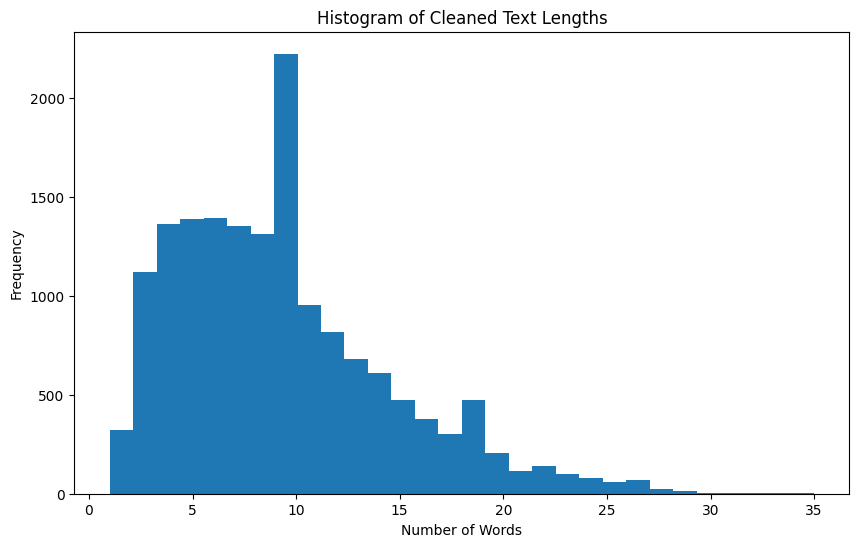


First 10 Text Lengths:


,cleaned_text,text_length
0,didnt feel humiliated,3
1,go feeling hopeless damned hopeful around some...,9
2,im grabbing minute post feel greedy wrong,7
3,ever feeling nostalgic fireplace know still pr...,7
4,feeling grouchy,2
5,ive feeling little burdened lately wasnt sure,7
6,ive taking milligrams times recommended amount...,15
7,feel confused life teenager jaded year old man,8
8,petronas years feel petronas performed well ma...,9
9,feel romantic,2


In [ ]:
# Q9. Text Length Analysis

import matplotlib.pyplot as plt

# Calculate number of words in each cleaned text
df['text_length'] = df['cleaned_text'].apply(
    lambda x: len(x.split())
)

# Print average, minimum and maximum text length
print("Text Length Analysis")
print("--------------------")

print("Average text length:", df['text_length'].mean())
print("Minimum text length:", df['text_length'].min())
print("Maximum text length:", df['text_length'].max())

# Plot histogram of text lengths
plt.figure(figsize=(10, 6))

plt.hist(df['text_length'], bins=30)

plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.title('Histogram of Cleaned Text Lengths')

plt.show()

# Display first 10 text lengths
print("\nFirst 10 Text Lengths:")
display(df[['cleaned_text', 'text_length']].head(10))

In [ ]:
# Q10. Mini Project - Full Preprocessing Pipeline

import pandas as pd
import string
import re
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords

# 1. Load the dataset
df_final = pd.read_csv(
    '/content/train.txt',
    sep=';',
    names=['text', 'emotions']
)

print("Dataset Loaded Successfully!")
print("Shape:", df_final.shape)


# 2. Encode the emotion labels
label_encoder_final = LabelEncoder()

df_final['emotion_encoded'] = label_encoder_final.fit_transform(
    df_final['emotions']
)

# Create emotion mapping
emotion_mapping_final = dict(
    zip(
        label_encoder_final.classes_,
        label_encoder_final.transform(label_encoder_final.classes_)
    )
)

print("\nEmotion Mapping:")
print(emotion_mapping_final)


# 3. Load English stopwords
english_stopwords_final = set(
    stopwords.words('english')
)


# Complete text cleaning function
def clean_text_final(text):

    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove emojis and special characters
    text = text.encode(
        'ascii',
        'ignore'
    ).decode('ascii')

    # Remove stopwords
    words = text.split()

    words = [
        word for word in words
        if word not in english_stopwords_final
    ]

    # Join words
    return ' '.join(words)


# Apply complete cleaning
df_final['cleaned_text'] = df_final['text'].apply(
    clean_text_final
)


# 4. Save cleaned dataset
df_final.to_csv(
    '/content/cleaned_emotions.csv',
    index=False
)

print("\nCleaned dataset saved successfully!")
print("File name: cleaned_emotions.csv")


# 5. Show value counts of each emotion
print("\nEmotion Value Counts:")
print(df_final['emotions'].value_counts())


# Display first 10 rows
print("\nFinal Dataset:")
display(df_final.head(10))

Dataset Loaded Successfully!
Shape: (16000, 2)

Emotion Mapping:
{'anger': np.int64(0), 'fear': np.int64(1), 'joy': np.int64(2), 'love': np.int64(3), 'sadness': np.int64(4), 'surprise': np.int64(5)}

Cleaned dataset saved successfully!
File name: cleaned_emotions.csv

Emotion Value Counts:
emotions
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

Final Dataset:


,text,emotions,emotion_encoded,cleaned_text
0,i didnt feel humiliated,sadness,4,didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,sadness,4,go feeling hopeless damned hopeful around some...
2,im grabbing a minute to post i feel greedy wrong,anger,0,im grabbing minute post feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,love,3,ever feeling nostalgic fireplace know still pr...
4,i am feeling grouchy,anger,0,feeling grouchy
5,ive been feeling a little burdened lately wasn...,sadness,4,ive feeling little burdened lately wasnt sure
6,ive been taking or milligrams or times recomme...,surprise,5,ive taking milligrams times recommended amount...
7,i feel as confused about life as a teenager or...,fear,1,feel confused life teenager jaded year old man
8,i have been with petronas for years i feel tha...,joy,2,petronas years feel petronas performed well ma...
9,i feel romantic too,love,3,feel romantic
